# Extra Credit #2 – Olivetti Faces (Image Classification)

**Implementation:** Vishal Hanuman  
**Algorithms:** k-NN (HW1) · Neural Network (HW4)  
**Dataset:** Olivetti faces — 400 images of 40 distinct subjects (10 images each), 64×64 grayscale.  
**Why this counts as a challenging dataset (EC#2 criterion):** image classification.  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

*Note:* Random Forest is omitted because the from-scratch implementation is too slow with 4096 input features. k-NN and Neural Network are well-suited to face recognition and were the top performers on the related Digits dataset.

In [1]:
import sys, os, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not Path('algorithms').exists():
    subprocess.run(['git', 'clone', 'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'algorithms').exists() and (PROJECT_ROOT.parent / 'algorithms').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


Project root: /home/vishal/code/classical-ml-benchmark


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

from sklearn.datasets import fetch_olivetti_faces
from algorithms.vishal import knn, neural_network, utils

np.random.seed(42)
os.makedirs('results', exist_ok=True)

DATA_PATH = Path('data/olivetti_faces.npz')
if DATA_PATH.exists():
    cached = np.load(DATA_PATH)
    X_raw = cached['X']
    y_int = cached['y']
else:
    data  = fetch_olivetti_faces(shuffle=True, random_state=42)
    X_raw = data.data.astype(float)       # (400, 4096), already in [0, 1]
    y_int = data.target.astype(int)       # (400,) ints 0..39
    np.savez_compressed(DATA_PATH, X=X_raw, y=y_int)

y = y_int.astype(str)   # string labels for CV helpers
X_norm, _ = utils.normalize(X_raw, X_raw)
folds = utils.stratified_k_fold(y, k=10)

def cross_validate_with_folds(model_fn, X, y_labels, pos_label, folds):
    accs, f1s = [], []
    for i in range(len(folds)):
        test_idx = np.array(folds[i])
        train_idx = np.array([idx for j in range(len(folds)) if j != i for idx in folds[j]])
        y_pred = model_fn(X[train_idx], y_labels[train_idx], X[test_idx])
        acc, f1 = utils.compute_metrics(y_labels[test_idx], y_pred, pos_label)
        accs.append(acc); f1s.append(f1)
    return float(np.mean(accs)), float(np.mean(f1s))

print(f"Instances: {len(y_int)}")
print(f"Features:  {X_raw.shape[1]}  (64 x 64 pixels)")
print(f"Classes:   {len(np.unique(y_int))}  (10 samples each)")


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/vishal/scikit_learn_data
Instances: 400
Features:  4096  (64 x 64 pixels)
Classes:   40  (10 samples each)


### Sample Faces

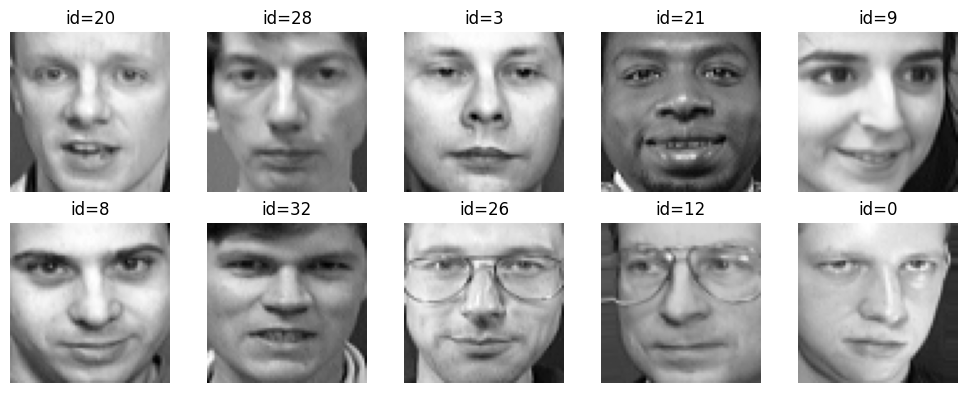

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
shown = set()
i = 0
for ax in axes.flat:
    while y_int[i] in shown:
        i += 1
    ax.imshow(X_raw[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'id={y_int[i]}')
    ax.axis('off')
    shown.add(y_int[i])
    i += 1
plt.tight_layout()
plt.savefig('results/olivetti_samples.png', dpi=120, bbox_inches='tight')
plt.show()


## k-NN – Hyperparameter Sweep (k)

10-fold stratified CV. With 10 samples per class, each fold receives 1 sample per class.

In [4]:
K_VALUES = [1, 3, 5, 7, 9, 11, 15]
knn_results = {}

for k in K_VALUES:
    def model_fn(Xtr, ytr, Xte, k=k):
        Xtr_n, Xte_n = utils.normalize(Xtr, Xte)
        return knn.predict(Xtr_n, ytr, Xte_n, k)
    acc, f1 = cross_validate_with_folds(model_fn, X_raw, y, pos_label=y[0], folds=folds)
    knn_results[k] = (acc, f1)
    print(f"k={k:>3}  acc={acc:.4f}  f1={f1:.4f}")


k=  1  acc=0.9575  f1=0.9442
k=  3  acc=0.9350  f1=0.9146
k=  5  acc=0.9075  f1=0.8806
k=  7  acc=0.8825  f1=0.8508
k=  9  acc=0.8400  f1=0.7973
k= 11  acc=0.8200  f1=0.7718
k= 15  acc=0.7425  f1=0.6812


Best k=1  acc=0.9575  f1=0.9442


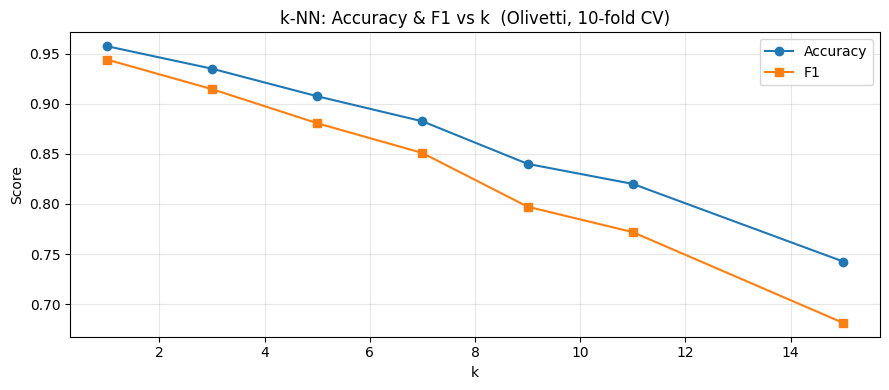

In [5]:
best_k = max(knn_results, key=lambda k: knn_results[k][1])
print(f"Best k={best_k}  acc={knn_results[best_k][0]:.4f}  f1={knn_results[best_k][1]:.4f}")

ks = list(knn_results.keys())
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, [knn_results[k][0] for k in ks], '-o', label='Accuracy')
ax.plot(ks, [knn_results[k][1] for k in ks], '-s', label='F1')
ax.set_xlabel('k'); ax.set_ylabel('Score')
ax.set_title('k-NN: Accuracy & F1 vs k  (Olivetti, 10-fold CV)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/olivetti_knn_k_sweep.png', dpi=150); plt.show()


## Neural Network – Hyperparameter Sweep (architecture × λ)

Output layer has 40 neurons (one-hot for 40 subjects); prediction via argmax.

In [6]:
N_CLASSES = 40
Y_oh = neural_network.one_hot(y_int, N_CLASSES)
folds_nn = folds

NN_CONFIGS = [
    ((64,),     0.0),
    ((128,),    0.0),
    ((64, 32),  0.0),
    ((128, 64), 0.0),
    ((128,),    0.1),
    ((128, 64), 0.1),
]

nn_results = {}
for arch, lam in NN_CONFIGS:
    accs, f1s = [], []
    for i in range(10):
        test_idx  = np.array(folds_nn[i])
        train_idx = np.array([idx for j in range(10) if j != i for idx in folds_nn[j]])
        Xtr, Xte  = X_norm[train_idx], X_norm[test_idx]
        Ytr       = Y_oh[train_idx]
        y_te_int  = y_int[test_idx]

        layer_sizes = [X_norm.shape[1]] + list(arch) + [N_CLASSES]
        theta, _    = neural_network.train(Xtr, Ytr, layer_sizes,
                                           lam=lam, alpha=0.5,
                                           epochs=400, batch_size=32)
        y_pred = neural_network.predict(theta, Xte)
        acc, f1 = utils.compute_metrics(y_te_int, y_pred, pos_label=0)
        accs.append(acc); f1s.append(f1)

    nn_results[(arch, lam)] = (float(np.mean(accs)), float(np.mean(f1s)))
    print(f"arch={str(arch):<12} lam={lam}  acc={np.mean(accs):.4f}  f1={np.mean(f1s):.4f}")


arch=(64,)        lam=0.0  acc=0.1975  f1=0.1194
arch=(128,)       lam=0.0  acc=0.2600  f1=0.1746
arch=(64, 32)     lam=0.0  acc=0.3175  f1=0.2244
arch=(128, 64)    lam=0.0  acc=0.8350  f1=0.8011
arch=(128,)       lam=0.1  acc=0.3350  f1=0.2583
arch=(128, 64)    lam=0.1  acc=0.5650  f1=0.4871


Best NN: arch=(128, 64)  lam=0.0
  acc=0.8350  f1=0.8011


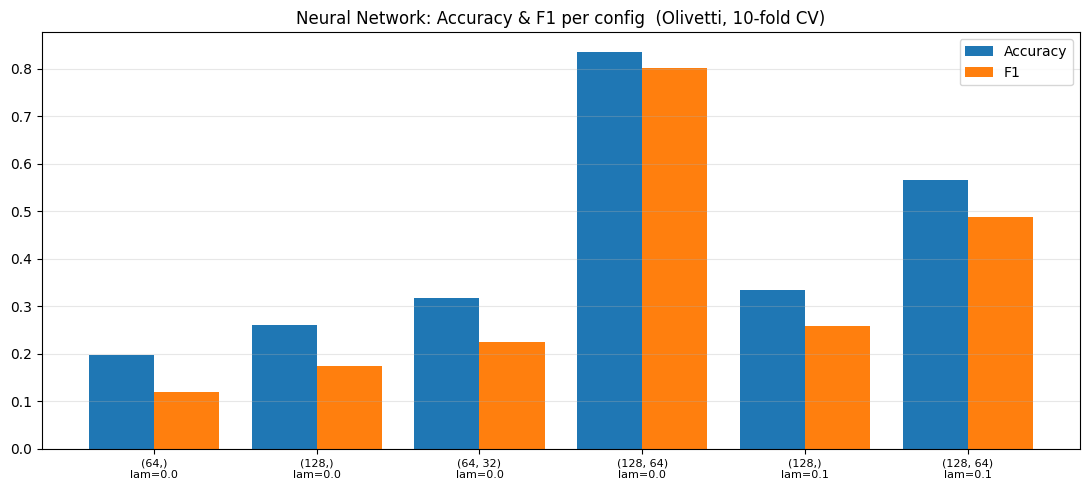

In [7]:
best_nn_key = max(nn_results, key=lambda k: nn_results[k][1])
best_arch, best_lam = best_nn_key
print(f"Best NN: arch={best_arch}  lam={best_lam}")
print(f"  acc={nn_results[best_nn_key][0]:.4f}  f1={nn_results[best_nn_key][1]:.4f}")

labels = [f"{str(a)}\nlam={l}" for a, l in nn_results]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, [nn_results[k][0] for k in nn_results], 0.4, label='Accuracy')
ax.bar(x + 0.2, [nn_results[k][1] for k in nn_results], 0.4, label='F1')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Neural Network: Accuracy & F1 per config  (Olivetti, 10-fold CV)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()
plt.savefig('results/olivetti_nn_config_sweep.png', dpi=150); plt.show()


### Neural Network – Learning Curve (J vs training instances)

n=  40  J=6.4450
n=  66  J=4.8686
n=  92  J=2.2002
n= 118  J=1.5809
n= 144  J=1.3798
n= 170  J=3.0310
n= 196  J=4.8697
n= 222  J=0.5766
n= 248  J=0.3494
n= 274  J=0.2586
n= 300  J=0.3056
n= 320  J=0.2968


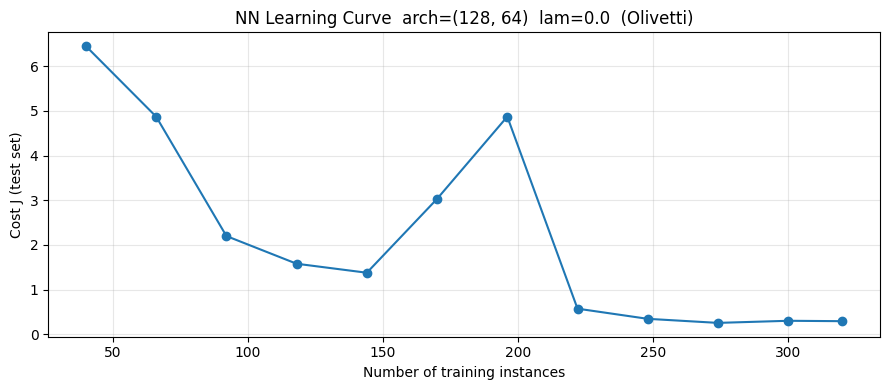

In [8]:
split = int(0.8 * len(y_int))
order = np.random.permutation(len(y_int))
tr_idx, te_idx = order[:split], order[split:]

Xtr_lc, Xte_lc = X_norm[tr_idx], X_norm[te_idx]
Ytr_lc = Y_oh[tr_idx]; Yte_lc = Y_oh[te_idx]

step  = max(20, split // 12)
sizes = list(range(40, split + 1, step))
if sizes[-1] != split: sizes.append(split)

lc_costs   = []
ls_best_nn = [X_norm.shape[1]] + list(best_arch) + [N_CLASSES]

for n in sizes:
    theta_lc, _ = neural_network.train(Xtr_lc[:n], Ytr_lc[:n], ls_best_nn,
                                        lam=best_lam, alpha=0.5,
                                        epochs=400, batch_size=32)
    J, _, _ = neural_network.cost(Xte_lc, Yte_lc, theta_lc, best_lam)
    lc_costs.append(J)
    print(f"n={n:>4}  J={J:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, lc_costs, '-o')
ax.set_xlabel('Number of training instances'); ax.set_ylabel('Cost J (test set)')
ax.set_title(f'NN Learning Curve  arch={best_arch}  lam={best_lam}  (Olivetti)')
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/olivetti_nn_learning_curve.png', dpi=150); plt.show()


## Summary – Olivetti Faces (EC#2)

In [9]:
print(f"{'Algorithm':<25} {'Best Hyperparameter':<22} {'Accuracy':>10} {'F1 Score':>10}")
print('-' * 72)
print(f"{'k-NN':<25} {'k='+str(best_k):<22} {knn_results[best_k][0]:>10.4f} {knn_results[best_k][1]:>10.4f}")
print(f"{'Neural Network':<25} {str(best_arch)+' l='+str(best_lam):<22} {nn_results[best_nn_key][0]:>10.4f} {nn_results[best_nn_key][1]:>10.4f}")


Algorithm                 Best Hyperparameter      Accuracy   F1 Score
------------------------------------------------------------------------
k-NN                      k=1                        0.9575     0.9442
Neural Network            (128, 64) l=0.0            0.8350     0.8011
